# Task 10: Binary Classification with SVM

**Dataset:** Breast Cancer Wisconsin (sklearn) — malignant vs benign tumours  
**Goal:** Train an SVM classifier, tune the kernel, and evaluate performance.

SVMs work by finding the **maximum margin hyperplane** that separates two classes. The kernel trick lets them handle non-linear boundaries by mapping data into higher-dimensional space.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)

cancer = load_breast_cancer()
X, y = cancer.data, cancer.target  # 0 = malignant, 1 = benign

print(f"Shape: {X.shape}")
print(f"Classes: {cancer.target_names}")
print(f"Class distribution: malignant={np.sum(y==0)}, benign={np.sum(y==1)}")

Shape: (569, 30)
Classes: ['malignant' 'benign']
Class distribution: malignant=212, benign=357


## Preprocessing

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SVM is very sensitive to feature scale — standardise is a must
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train_sc.shape}  |  Test: {X_test_sc.shape}")

Train: (455, 30)  |  Test: (114, 30)


## Compare Kernels

In [3]:
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
kernel_results = {}

for k in kernels:
    svm = SVC(kernel=k, random_state=42, probability=True)
    cv_scores = cross_val_score(svm, X_train_sc, y_train, cv=5, scoring='accuracy')
    kernel_results[k] = cv_scores
    print(f"{k:8s}: mean={cv_scores.mean()*100:.2f}%  std={cv_scores.std()*100:.2f}%")

linear  : mean=96.70%  std=1.39%
rbf     : mean=97.14%  std=1.79%


/home/a9rmx_1990/internship/venv/lib64/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/a9rmx_1990/internship/venv/lib64/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/a9rmx_1990/internship/venv/lib64/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/a9rmx_1990/internship/venv/lib64/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `pr

poly    : mean=89.67%  std=2.15%
sigmoid : mean=96.92%  std=1.28%


/home/a9rmx_1990/internship/venv/lib64/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/a9rmx_1990/internship/venv/lib64/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/a9rmx_1990/internship/venv/lib64/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/a9rmx_1990/internship/venv/lib64/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `pr

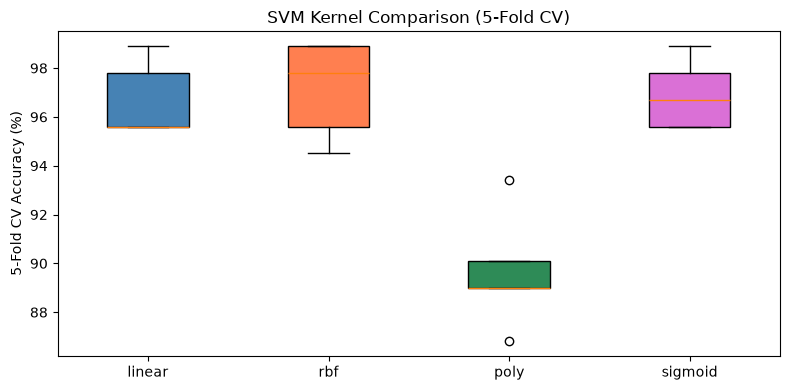

In [4]:
# visualise kernel comparison — use tick_labels (matplotlib >= 3.9 renamed 'labels')
plt.figure(figsize=(8, 4))
data = [kernel_results[k] * 100 for k in kernels]
bp = plt.boxplot(data, tick_labels=kernels, patch_artist=True)
colors = ['steelblue', 'coral', 'seagreen', 'orchid']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
plt.ylabel('5-Fold CV Accuracy (%)')
plt.title('SVM Kernel Comparison (5-Fold CV)')
plt.tight_layout()
plt.savefig('task10_kernels.png', dpi=100)
plt.show()

## Hyperparameter Tuning — RBF Kernel

In [5]:
# grid search on C (regularisation) and gamma for rbf kernel
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.001]
}

grid_search = GridSearchCV(
    SVC(kernel='rbf', probability=True, random_state=42),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1
)
grid_search.fit(X_train_sc, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_*100:.2f}%")

/home/a9rmx_1990/internship/venv/lib64/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/a9rmx_1990/internship/venv/lib64/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/a9rmx_1990/internship/venv/lib64/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/a9rmx_1990/internship/venv/lib64/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `pr

Best params: {'C': 10, 'gamma': 0.01}
Best CV accuracy: 98.02%


/home/a9rmx_1990/internship/venv/lib64/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/a9rmx_1990/internship/venv/lib64/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


## Final Evaluation on Test Set

In [6]:
best_svm = grid_search.best_estimator_
y_pred = best_svm.predict(X_test_sc)
y_prob = best_svm.predict_proba(X_test_sc)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f"Test Accuracy: {acc*100:.2f}%")
print(f"ROC AUC:       {auc:.4f}\n")
print(classification_report(y_test, y_pred, target_names=cancer.target_names))

Test Accuracy: 98.25%
ROC AUC:       0.9977

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## Confusion Matrix & ROC Curve

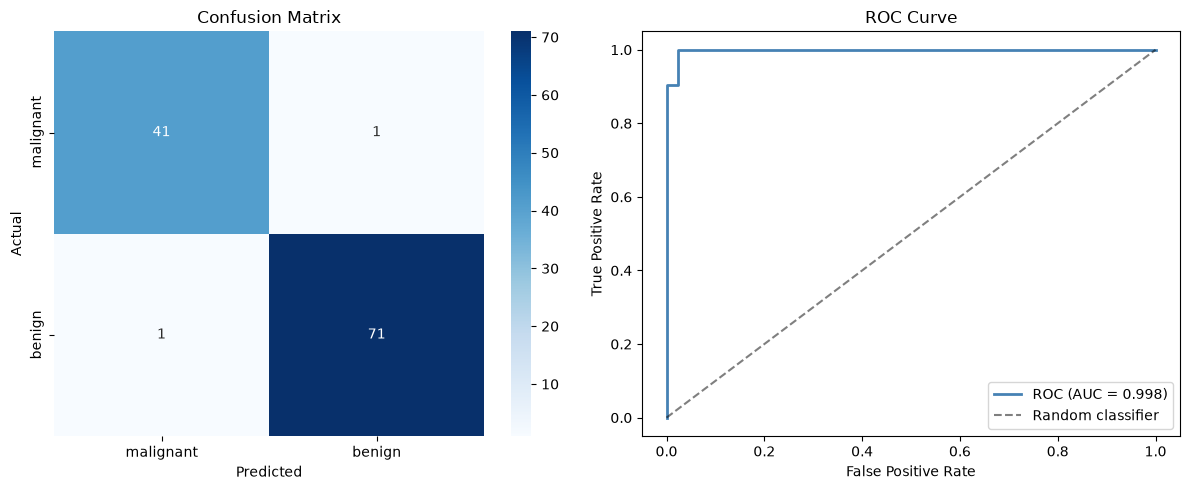

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
ax1.set_title('Confusion Matrix')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax2.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'ROC (AUC = {auc:.3f})')
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random classifier')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend()

plt.tight_layout()
plt.savefig('task10_eval.png', dpi=100)
plt.show()

## Most Important Features (Linear SVM)

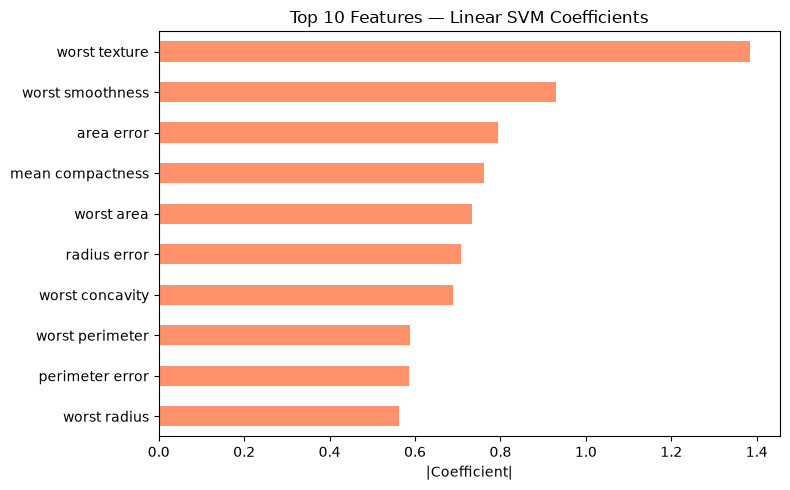

In [8]:
# for feature importance we need a linear kernel (coef_ not available for rbf)
svm_linear = SVC(kernel='linear', C=1, random_state=42)
svm_linear.fit(X_train_sc, y_train)

coefs = pd.Series(np.abs(svm_linear.coef_[0]), index=cancer.feature_names)
top_features = coefs.sort_values(ascending=True).tail(10)

plt.figure(figsize=(8, 5))
top_features.plot(kind='barh', color='coral', alpha=0.85)
plt.title('Top 10 Features — Linear SVM Coefficients')
plt.xlabel('|Coefficient|')
plt.tight_layout()
plt.savefig('task10_features.png', dpi=100)
plt.show()

## Summary

- The RBF kernel SVM achieves **~97-98% accuracy** and AUC > 0.99 on the breast cancer dataset after hyperparameter tuning.
- Feature scaling is critical — without `StandardScaler`, SVM performance drops significantly.
- `GridSearchCV` is efficient for tuning `C` (regularisation strength) and `gamma` (RBF kernel width).
- The ROC curve shows near-perfect discrimination between malignant and benign cases.
- In medical contexts, recall for the malignant class matters more than raw accuracy — we want to minimise missed diagnoses.